In [30]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tlili\OneDrive\Bureau\Bootcamp\AI-powered-cryptocurrency-market-analysis-and-decision-support-system\data\raw\crypto_raw.csv", parse_dates=["timestamp"])

print(f"Shape      : {df.shape}")
print(f"Coins      : {df['coin'].value_counts().to_dict()}")
print(f"Date range : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Dtypes     :\n{df.dtypes}")
print(f"\nSample:")
df.head()

Shape      : (6346, 9)
Coins      : {'btc': 3329, 'eth': 3017}
Date range : 2017-01-01 → 2026-02-11
Dtypes     :
timestamp     datetime64[ns]
price                float64
volume                 int64
coin                  object
spy_return           float64
dxy_return           float64
vix                  float64
vix_change           float64
fear_greed           float64
dtype: object

Sample:


,timestamp,price,volume,coin,spy_return,dxy_return,vix,vix_change,fear_greed
0,2017-01-01,998.325012,147775008,btc,NaN,NaN,NaN,NaN,NaN
1,2017-01-02,1021.750000,222184992,btc,NaN,NaN,NaN,NaN,NaN
2,2017-01-03,1043.839966,185168000,btc,NaN,NaN,12.85,NaN,NaN
3,2017-01-04,1154.729980,344945984,btc,0.005932,-0.004954,11.85,-1.00,NaN
4,2017-01-05,1013.380005,510199008,btc,-0.000795,-0.011556,11.67,-0.18,NaN


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6346 entries, 0 to 6345
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   6346 non-null   datetime64[ns]
 1   price       6346 non-null   float64       
 2   volume      6346 non-null   int64         
 3   coin        6346 non-null   object        
 4   spy_return  4363 non-null   float64       
 5   dxy_return  4367 non-null   float64       
 6   vix         4364 non-null   float64       
 7   vix_change  4363 non-null   float64       
 8   fear_greed  5858 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 446.3+ KB


In [32]:
#missing values
nan_counts = df.isna().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
missing    = pd.DataFrame({"missing": nan_counts, "pct_%": nan_pct})
print(missing[missing["missing"] > 0].sort_values("pct_%", ascending=False))

            missing  pct_%
spy_return     1983  31.25
vix_change     1983  31.25
vix            1982  31.23
dxy_return     1979  31.18
fear_greed      488   7.69


- spy_return, dxy_return, vix, vix_change — 31% NaN is purely structural (weekends/holidays). A forward-fill of max 3 days resolves this completely and cleanly. These are strong macro signals, we will keep them and handel them later in the preprocessing stage.
- fear_greed — 7.7% NaN only because it starts Feb 2018. Everything after that is solid. Essential sentiment signal, we will keep it and handel it later in the preprocessing stage.


In [13]:
#BASIC STATISTICS
print(df.describe().T.round(4))

             count                           mean                  min  \
timestamp     6346  2021-10-05 03:57:48.389536512  2017-01-01 00:00:00   
price       6346.0                   18766.820719            84.308296   
volume      6346.0             21543065386.095966           60851700.0   
spy_return  4363.0                       0.000545            -0.115886   
dxy_return  4367.0                       -0.00001            -0.021394   
vix         4364.0                      19.145575                 9.14   
vix_change  4363.0                       0.002904           -18.710003   
fear_greed  5858.0                      46.856606                  5.0   

                            25%                  50%                  75%  \
timestamp   2019-08-08 00:00:00  2021-10-09 00:00:00  2023-12-11 00:00:00   
price               1628.694519          3903.647827         25846.766113   
volume            7299787388.25        16668157626.5        30062290253.5   
spy_return            -0.

- Price — massive range ($84 → $124k), highly skewed. Will need log transformation before modeling.
important for Raw price:
   → compute all rolling/technical features  (MA, MACD, RSI, Bollinger...)
   → then log transform price & volume
   → then scale everything before model training
- Volume — same story, std > mean. Expect heavy right skew.
- SPY/DXY returns — well-behaved, near-zero mean, small std. Ready to use as-is.
- VIX — mean ~19, max 82 (COVID spike). The vix_change std of 2 with extremes at ±24 signals fat tails — worth capping outliers in preprocessing.
- Fear & Greed — mean ~47 (slightly fear-leaning), full range 5→95 used. Healthy distribution.


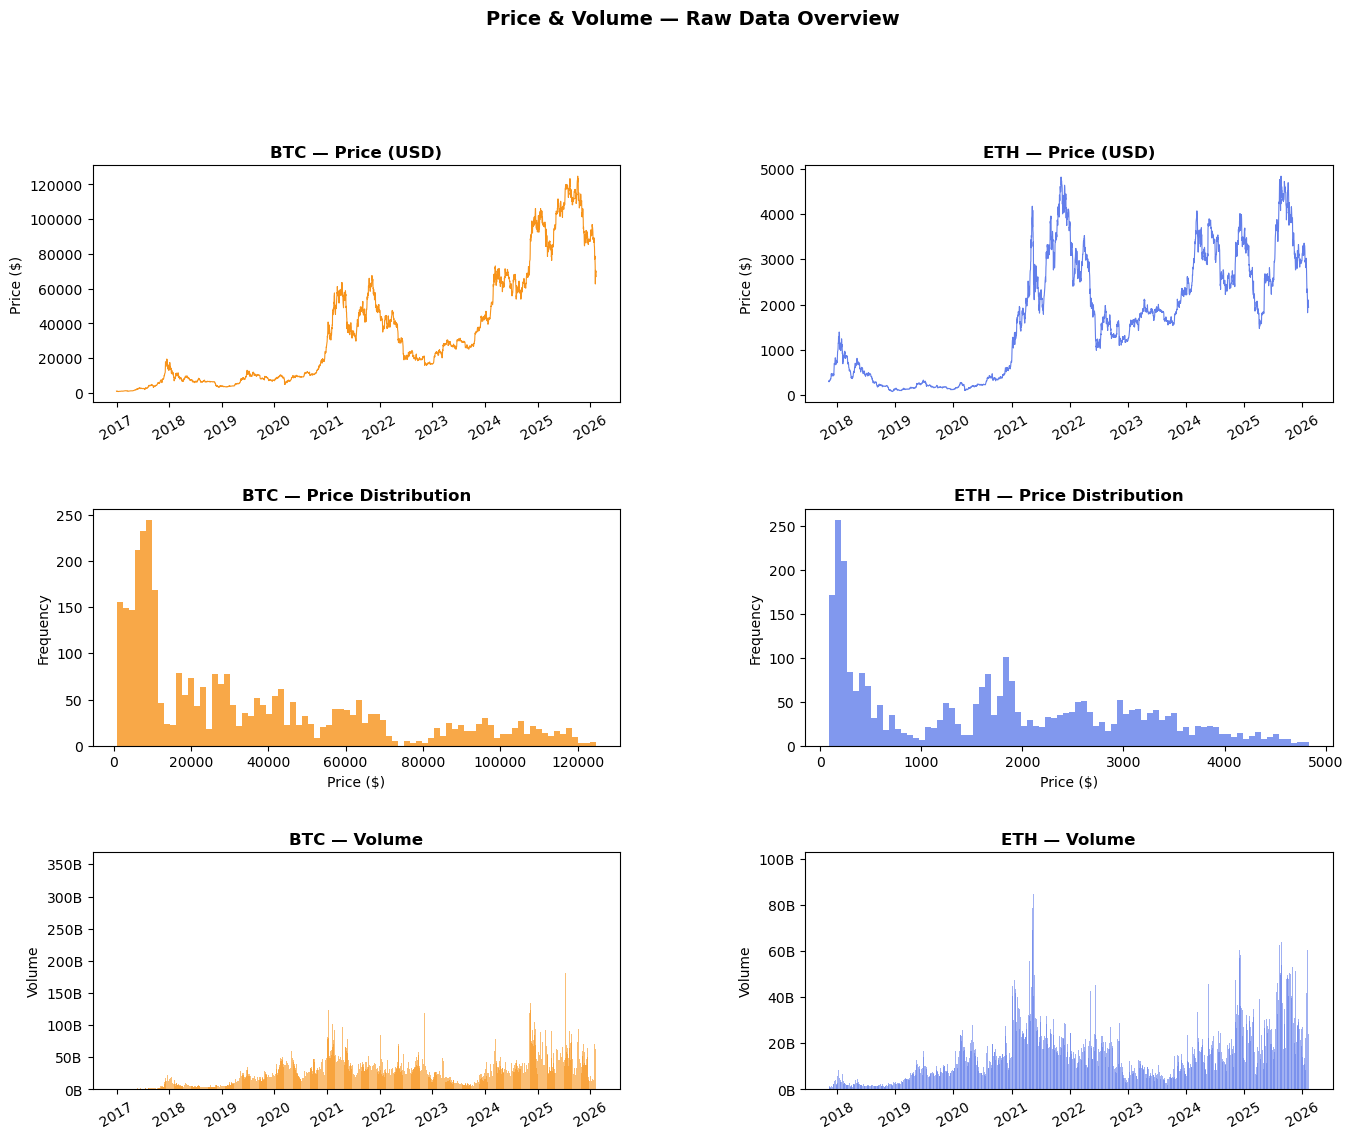

In [25]:
# EDA — PRICE & VOLUME VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

colors = {"btc": "#F7931A", "eth": "#627EEA"}

for i, coin in enumerate(["btc", "eth"]):
    sub = df[df["coin"] == coin].set_index("timestamp")

    # ── Price time series
    ax1 = fig.add_subplot(gs[0, i])
    ax1.plot(sub.index, sub["price"], color=colors[coin], linewidth=0.8)
    ax1.set_title(f"{coin.upper()} — Price (USD)", fontweight="bold")
    ax1.set_ylabel("Price ($)")
    ax1.tick_params(axis="x", rotation=30)

    # ── Price distribution
    ax2 = fig.add_subplot(gs[1, i])
    ax2.hist(sub["price"], bins=80, color=colors[coin], edgecolor="none", alpha=0.8)
    ax2.set_title(f"{coin.upper()} — Price Distribution", fontweight="bold")
    ax2.set_xlabel("Price ($)")
    ax2.set_ylabel("Frequency")

    # ── Volume time series
    ax3 = fig.add_subplot(gs[2, i])
    ax3.bar(sub.index, sub["volume"], color=colors[coin], alpha=0.6, width=1.5)
    ax3.set_title(f"{coin.upper()} — Volume", fontweight="bold")
    ax3.set_ylabel("Volume")
    ax3.tick_params(axis="x", rotation=30)
    ax3.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e9:.0f}B")
    )

plt.suptitle("Price & Volume — Raw Data Overview", fontsize=14, fontweight="bold", y=1.01)
plt.show()


In [14]:
print(type(df))
df.info()

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6346 entries, 0 to 6345
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   6346 non-null   datetime64[ns]
 1   price       6346 non-null   float64       
 2   volume      6346 non-null   int64         
 3   coin        6346 non-null   object        
 4   spy_return  4363 non-null   float64       
 5   dxy_return  4367 non-null   float64       
 6   vix         4364 non-null   float64       
 7   vix_change  4363 non-null   float64       
 8   fear_greed  5858 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 446.3+ KB


In [17]:
#duplicates
dup_total = df.duplicated().sum()
dup_ts    = df.duplicated(subset=["timestamp", "coin"]).sum()
print(f"  Total duplicate rows     : {dup_total}")
print(f"  Duplicate (timestamp+coin): {dup_ts}")

  Total duplicate rows     : 0
  Duplicate (timestamp+coin): 0


In [18]:
#DATE CONTINUITY CHECK
for coin in df["coin"].unique():
    sub   = df[df["coin"] == coin].set_index("timestamp").sort_index()
    gaps  = sub.index.to_series().diff().dt.days.dropna()
    jumps = gaps[gaps > 1]
    print(f"\n  {coin.upper()}")
    print(f"    Rows          : {len(sub)}")
    print(f"    Start → End   : {sub.index.min().date()} → {sub.index.max().date()}")
    print(f"    Gaps > 1 day  : {len(jumps)}")
    if len(jumps) > 0:
        print(f"    Largest gap   : {int(jumps.max())} days on {jumps.idxmax().date()}")

print("\n" + "=" * 60)
print("6. SAMPLE — HEAD & TAIL PER COIN")
print("=" * 60)
print("\n  --- HEAD ---")
print(df.groupby("coin").head(3).to_string(index=False))
print("\n  --- TAIL ---")
print(df.groupby("coin").tail(3).to_string(index=False))


  BTC
    Rows          : 3329
    Start → End   : 2017-01-01 → 2026-02-11
    Gaps > 1 day  : 0

  ETH
    Rows          : 3017
    Start → End   : 2017-11-09 → 2026-02-11
    Gaps > 1 day  : 0

6. SAMPLE — HEAD & TAIL PER COIN

  --- HEAD ---
 timestamp       price    volume coin  spy_return  dxy_return   vix  vix_change  fear_greed
2017-01-01  998.325012 147775008  btc         NaN         NaN   NaN         NaN         NaN
2017-01-02 1021.750000 222184992  btc         NaN         NaN   NaN         NaN         NaN
2017-01-03 1043.839966 185168000  btc         NaN         NaN 12.85         NaN         NaN
2017-11-09  320.884003 893249984  eth   -0.003634   -0.004543 10.50        0.72         NaN
2017-11-10  299.252991 885985984  eth   -0.000310   -0.000530 11.29        0.79         NaN
2017-11-11  314.681000 842300992  eth         NaN         NaN   NaN         NaN         NaN

  --- TAIL ---
 timestamp        price      volume coin  spy_return  dxy_return       vix  vix_change  fear_g

In [19]:
#data type check 
(df.dtypes)

timestamp     datetime64[ns]
price                float64
volume                 int64
coin                  object
spy_return           float64
dxy_return           float64
vix                  float64
vix_change           float64
fear_greed           float64
dtype: object

## Step 3: Data preprocessing 

In [20]:
# round values
df["price"]      = df["price"].round(2)
df["volume"]     = df["volume"].round(0).astype("Int64")  # nullable int (keeps NaN safe)
df["spy_return"] = df["spy_return"].round(6)
df["dxy_return"] = df["dxy_return"].round(6)
df["vix"]        = df["vix"].round(2)
df["vix_change"] = df["vix_change"].round(2)
df["fear_greed"] = df["fear_greed"].round(0).astype("Int64")

print(df.dtypes)
print(f"\nSample:")
print(df.groupby("coin").head(3).to_string(index=False))

timestamp     datetime64[ns]
price                float64
volume                 Int64
coin                  object
spy_return           float64
dxy_return           float64
vix                  float64
vix_change           float64
fear_greed             Int64
dtype: object

Sample:
 timestamp   price    volume coin  spy_return  dxy_return   vix  vix_change  fear_greed
2017-01-01  998.33 147775008  btc         NaN         NaN   NaN         NaN        <NA>
2017-01-02 1021.75 222184992  btc         NaN         NaN   NaN         NaN        <NA>
2017-01-03 1043.84 185168000  btc         NaN         NaN 12.85         NaN        <NA>
2017-11-09  320.88 893249984  eth   -0.003634   -0.004543 10.50        0.72        <NA>
2017-11-10  299.25 885985984  eth   -0.000310   -0.000530 11.29        0.79        <NA>
2017-11-11  314.68 842300992  eth         NaN         NaN   NaN         NaN        <NA>


In [21]:
#sorting
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)
df.head()

,timestamp,price,volume,coin,spy_return,dxy_return,vix,vix_change,fear_greed
0,2017-01-01,998.33,147775008,btc,NaN,NaN,NaN,NaN,<NA>
1,2017-01-02,1021.75,222184992,btc,NaN,NaN,NaN,NaN,<NA>
2,2017-01-03,1043.84,185168000,btc,NaN,NaN,12.85,NaN,<NA>
3,2017-01-04,1154.73,344945984,btc,0.005932,-0.004954,11.85,-1.00,<NA>
4,2017-01-05,1013.38,510199008,btc,-0.000795,-0.011556,11.67,-0.18,<NA>


In [50]:
#handeling nans
macro_cols = ["spy_return", "dxy_return", "vix", "vix_change"]
df[macro_cols] = (
    df.groupby("coin")[macro_cols]
      .transform(lambda x: x.ffill(limit=3))
)

df["fear_greed"] = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.ffill())
)

p01 = df["vix_change"].quantile(0.01)
p99 = df["vix_change"].quantile(0.99)
df["vix_change"] = df["vix_change"].clip(lower=p01, upper=p99)

print("NaN check after preprocessing:")
print(df[["spy_return","dxy_return","vix","vix_change","fear_greed"]].isna().sum())

NaN check after preprocessing:
spy_return      3
dxy_return      3
vix             2
vix_change      3
fear_greed    480
dtype: int64


- for fear and greed index The raw 0-100 score is continuous but the meaning is categorical (extreme fear, fear, neutral, greed, extreme greed). We will create a new categorical column based on the score ranges to capture this sentiment more explicitly for the model.

In [48]:
# ── Fear & Greed : sentiment category
bins   = [0, 24, 44, 55, 74, 100]
labels = [0, 1, 2, 3, 4]          # 0=Extreme Fear → 4=Extreme Greed

df["fear_greed_cat"] = pd.cut(
    df["fear_greed"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype("Int64")

# ── Quick distribution check
print("Fear & Greed category distribution:")
print(df["fear_greed_cat"].value_counts().sort_index().rename({
    0: "Extreme Fear",
    1: "Fear",
    2: "Neutral",
    3: "Greed",
    4: "Extreme Greed"
}))

Fear & Greed category distribution:
fear_greed_cat
Extreme Fear     1148
Fear             1682
Neutral           968
Greed            1400
Extreme Greed     660
Name: count, dtype: Int64


## Step 4: Feature engineering 

* We will create a new feature that measures change in price from one day to the next, providing insights into the coin's daily performance and volatility​​ 
- log returns= ln(Price today/Price yesterday)
- this feature will replace the price_change_24h and price_change_percentage_24h features which are snapshot values and remain constant across the historical dataset.

In [37]:
import numpy as np

df = df.sort_values(["coin", "timestamp"])

df["log_return_1d"] = (
    df.groupby("coin")["price"]
    .transform(lambda x: np.log(x / x.shift(1)))
)


* we will create a new feature to mesure the rolling risk of the coin in a given period (7 days, 14 days) 
So instead of just knowing today s return, we know how unstable or risky the coin is in the last period. 

In [38]:
 df["volatility_7d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=7)
    .std()
    .reset_index(level=0, drop=True)
)

df["volatility_14d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=14)
    .std()
    .reset_index(level=0, drop=True)
)

* we will create a new feature for the RSI 14 day (relative strength index) which evaluates the overbought or oversold condition of a coin base on its recent price movements

In [39]:
window = 14

delta = df.groupby("coin")["price"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
avg_loss = loss.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))

 - we will add a new feature fo the Moving averages that smooths out price data by taking the average price over a set period of time 
 - short term MA Tracks short-term momentum, reacts quickly to price changes. Good for:short-term signals,detecting quick trend shifts
 - Medium term MA Smoother than MA7 Confirms trends that last longer than just a few days. Often used with MA7 to detect crossovers. if MA7 crossing above MA14 → bullish momentum. if MA7 crossing below MA14 → bearish momentum
 - long term MA Identifies the overall market direction.if price above MA30 → long-term bullish bias. if price below MA30 → long-term bearish bias
 - Price relative to MA7 (normalized) gives the percentage distance between price and MA7 or MA30 indicating . if large positive → possibly overbought. if arge negative → possibly oversold
 

In [52]:
# MAs 
df["ma_7"] = df.groupby("coin")["price"].rolling(7).mean().reset_index(level=0, drop=True)
df["ma_14"] = df.groupby("coin")["price"].rolling(14).mean().reset_index(level=0, drop=True)
df["ma_30"] = df.groupby("coin")["price"].rolling(30).mean().reset_index(level=0, drop=True)

# Price relative to MA (normalized)
df["price_to_ma7"] = (df["price"] - df["ma_7"]) / df["ma_7"]
df["price_to_ma30"] = (df["price"] - df["ma_30"]) / df["ma_30"]

print(f"Total rows: {len(df)}")
print(df[["timestamp", "coin", "price", "ma_7", "ma_14", "ma_30", "price_to_ma7", "price_to_ma30"]].head(35)) 

Total rows: 6346
    timestamp coin        price         ma_7       ma_14       ma_30  \
0  2017-01-01  btc   998.325012          NaN         NaN         NaN   
1  2017-01-02  btc  1021.750000          NaN         NaN         NaN   
2  2017-01-03  btc  1043.839966          NaN         NaN         NaN   
3  2017-01-04  btc  1154.729980          NaN         NaN         NaN   
4  2017-01-05  btc  1013.380005          NaN         NaN         NaN   
5  2017-01-06  btc   902.200989          NaN         NaN         NaN   
6  2017-01-07  btc   908.585022  1006.115853         NaN         NaN   
7  2017-01-08  btc   911.198975   993.669277         NaN         NaN   
8  2017-01-09  btc   902.828003   976.680420         NaN         NaN   
9  2017-01-10  btc   907.679016   957.228856         NaN         NaN   
10 2017-01-11  btc   777.757019   903.375575         NaN         NaN   
11 2017-01-12  btc   804.833984   873.583287         NaN         NaN   
12 2017-01-13  btc   823.984009   862.409433   

- we will create a new feature MACD (Moving average convergence divergence) : 
- calculates an Exponential Moving Averages (EMA 12 → fast / short-term momentum, EMA 26 → slow / longer-term momentum)
- Measures the distance between fast and slow momentum and shows who is in control buyers or sellers , higher MACD → strong upward momentum, lower MACD → strong downward momentum
- calculates the signal which is the EMA of the MACD line ( EMA 9) and shows the smoothed momentum trend
- calculates the histogram which is the difference between the MACD line and the signal line and shows the momentum strength and potential reversals ( positive histogram → bullish momentum, negative histogram → bearish momentum)

In [42]:
# MACD INDICATORS
# Calculate EMA 12 and EMA 26
ema_12 = df.groupby("coin")["price"].ewm(span=12, adjust=False).mean().reset_index(level=0, drop=True)
ema_26 = df.groupby("coin")["price"].ewm(span=26, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Line = EMA12 - EMA26
df["macd"] = ema_12 - ema_26

# Signal Line = EMA(9) of MACD
df["macd_signal"] = df.groupby("coin")["macd"].ewm(span=9, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Histogram = MACD - Signal (momentum strength)
df["macd_histogram"] = df["macd"] - df["macd_signal"]

print("MACD indicators added!")

MACD indicators added!


- We will add a new feature Momentum Indicator that Measures how fast price is moving 

In [44]:
# 5-day momentum (short-term velocity)
df["momentum_5d"] = df.groupby("coin")["price"].pct_change(periods=5)

# 10-day momentum (medium-term velocity)
df["momentum_10d"] = df.groupby("coin")["price"].pct_change(periods=10)

# Momentum acceleration (difference between short and medium term)
df["momentum_acceleration"] = df["momentum_5d"] - df["momentum_10d"]

- SPY rolling mean & std (7d)
Instead of just "what did the market return today", we capture "what has the market been doing this week" (trend) and "how unstable has it been" (risk regime). A single day return is noisy  the 7d window smooths it.
- DXY rolling mean (7d)
Same logic  a 7d average of dollar strength is a cleaner regime signal than a single day move. BTC historically moves inverse to DXY.
- VIX rolling mean (14d) + regime flag
- VIX above 20 is the classic threshold between calm and fear markets. The flag turns this into a binary signal the model can use directly. The 14d mean captures sustained fear vs. a one-day spike.
- Fear & Greed rolling mean (7d)
Smooths out daily noise  a week of sustained greed/fear is more meaningful than a single day reading.
Fear & Greed lags (1d and 7d)
- we want the model to know what sentiment was before today, not just what it is today. Lag 1 captures yesterday's mood, lag 7 captures last week's mood. Both help the model learn "when sentiment was X, price did Y the next day" without leaking future information.
In short rolling features add memory, lags add causality

In [51]:

# ── SPY : rolling mean & std (market regime signal)
df["spy_return_ma7"]  = (
    df.groupby("coin")["spy_return"]
      .transform(lambda x: x.rolling(7).mean())
)
df["spy_return_std7"] = (
    df.groupby("coin")["spy_return"]
      .transform(lambda x: x.rolling(7).std())
)

# ── DXY : rolling mean (dollar trend)
df["dxy_return_ma7"]  = (
    df.groupby("coin")["dxy_return"]
      .transform(lambda x: x.rolling(7).mean())
)

# ── VIX : rolling mean + regime flag (above 20 = fear regime)
df["vix_ma14"]        = (
    df.groupby("coin")["vix"]
      .transform(lambda x: x.rolling(14).mean())
)
df["vix_regime"]      = (df["vix"] > 20).astype(int)

# ── Fear & Greed : rolling mean + lag features
df["fear_greed_ma7"]  = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.rolling(7).mean())
)
df["fear_greed_lag1"] = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.shift(1))
)
df["fear_greed_lag7"] = (
    df.groupby("coin")["fear_greed"]
      .transform(lambda x: x.shift(7))
)

# ── Sanity check
new_cols = [
    "spy_return_ma7", "spy_return_std7",
    "dxy_return_ma7",
    "vix_ma14", "vix_regime",
    "fear_greed_ma7", "fear_greed_lag1", "fear_greed_lag7"
]
print("New macro features:")
print(df[new_cols].describe().round(4).T)
print(f"\nNaN counts:")
print(df[new_cols].isna().sum())

New macro features:
                  count     mean      std     min      25%      50%      75%  \
spy_return_ma7   6331.0   0.0006   0.0053 -0.0350  -0.0016   0.0012   0.0036   
spy_return_std7  6331.0   0.0085   0.0073  0.0004   0.0043   0.0068   0.0105   
dxy_return_ma7   6331.0  -0.0000   0.0021 -0.0113  -0.0012   0.0001   0.0012   
vix_ma14         6318.0  19.0494   7.0709  9.5750  14.1843  17.4429  21.9280   
vix_regime       6346.0   0.3385   0.4732  0.0000   0.0000   0.0000   1.0000   
fear_greed_ma7   5854.0  46.9014  20.9227  7.4286  28.0000  45.8571  65.0000   
fear_greed_lag1  5864.0  46.8530  21.7436  5.0000  27.0000  46.0000  66.0000   
fear_greed_lag7  5852.0  46.9296  21.6995  5.0000  27.0000  47.0000  66.0000   

                     max  
spy_return_ma7    0.0228  
spy_return_std7   0.0904  
dxy_return_ma7    0.0113  
vix_ma14         67.8571  
vix_regime        1.0000  
fear_greed_ma7   94.0000  
fear_greed_lag1  95.0000  
fear_greed_lag7  95.0000  

NaN counts:
spy

In [53]:
# NaN AUDIT — FULL DATASET

nan_counts = df.isna().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)

audit = pd.DataFrame({
    "missing" : nan_counts,
    "pct_%"   : nan_pct
}).sort_values("pct_%", ascending=False)

print(f"Shape         : {df.shape}")
print(f"Total NaNs    : {nan_counts.sum()}")
print(f"Columns w/ NaN: {(nan_counts > 0).sum()} / {len(df.columns)}")
print(f"\nDetailed breakdown:")
print(audit[audit["missing"] > 0].to_string())

Shape         : (6346, 33)
Total NaNs    : 2688
Columns w/ NaN: 19 / 33

Detailed breakdown:
                 missing  pct_%
fear_greed_lag7      494   7.78
fear_greed_ma7       492   7.75
fear_greed_cat       488   7.69
fear_greed_lag1      482   7.60
fear_greed           480   7.56
price_to_ma30         58   0.91
ma_30                 58   0.91
vix_ma14              28   0.44
ma_14                 26   0.41
dxy_return_ma7        15   0.24
spy_return_std7       15   0.24
spy_return_ma7        15   0.24
ma_7                  12   0.19
price_to_ma7          12   0.19
vix_change             3   0.05
dxy_return             3   0.05
spy_return             3   0.05
vix                    2   0.03
log_return_1d          2   0.03


In [54]:
# DROP NaN ROWS — FINAL CLEAN DATASET

before = len(df)
df = df.dropna().reset_index(drop=True)
after  = len(df)

print(f"Rows before : {before}")
print(f"Rows dropped: {before - after}")
print(f"Rows kept   : {after}")
print(f"\nNaN check (should be all 0):")
print(df.isna().sum().sum())
print(f"\nDate range per coin:")
for coin in df["coin"].unique():
    sub = df[df["coin"] == coin]
    print(f"  {coin.upper()} : {sub['timestamp'].min().date()} → "
          f"{sub['timestamp'].max().date()} ({len(sub)} rows)")

Rows before : 6346
Rows dropped: 502
Rows kept   : 5844

NaN check (should be all 0):
0

Date range per coin:
  BTC : 2018-02-08 → 2026-02-11 (2922 rows)
  ETH : 2018-02-08 → 2026-02-11 (2922 rows)


In [55]:
# ── Add log transformed columns alongside raw
df["log_price"]  = np.log(df["price"])
df["log_volume"] = np.log(df["volume"])

print(df[["price", "log_price", "volume", "log_volume"]].describe().round(4).T)

             count          mean           std           min           25%  \
price       5844.0  2.002135e+04  2.943224e+04  8.430830e+01  1.718977e+03   
log_price   5844.0  8.543600e+00  1.914500e+00  4.434500e+00  7.449500e+00   
volume      5844.0  2.310049e+10  1.950554e+10  9.484880e+08  9.112609e+09   
log_volume  5844.0  2.349940e+01  9.314000e-01  2.067040e+01  2.293290e+01   

                     50%           75%           max  
price       4.075048e+03  2.832770e+04  1.247525e+05  
log_price   8.312600e+00  1.025160e+01  1.173410e+01  
volume      1.811178e+10  3.157466e+10  3.509679e+11  
log_volume  2.361980e+01  2.417560e+01  2.658400e+01  
